In [1]:
import env
from CADGNTrainer import CADGNTrainer, Stage1Config, Stage2Config
from CADGNCore import CADGNCore
from TokenizerFamily import TokenizerFamily
from losses import _generate_candidate_pairs
from models_config import models
from ds.cladder import CLadderDataset, CLadderSample, load_cladder_v1_5, CLadderLoaderConfig
from cadgn import save_history, flush_gpu
import seaborn as sns
import pandas as pd
import math

flush_gpu()

GPU: 0.00GB allocated / 0.00GB reserved


In [2]:
## Configuration
ca_dgn_dim = 256
max_seq_len = 128
do_models = ["Qwen/Qwen3-1.7B", "Qwen/Qwen3-4B", "meta-llama/Llama-3.2-1B", "meta-llama/Llama-3.2-3B"]
max_samples_per_epoch = 550

dsConfig = CLadderLoaderConfig(rung_filter=None, query_types=None, skip_unparseable=True)
org_ds = load_cladder_v1_5(dsConfig)

Processing 10112 rows...
Loaded 8532 graphs, skipped 1580 unparseable rows.


In [3]:
# Train-Test Split
train, vald = CLadderDataset.from_samples_split(
    samples=org_ds,
    val_size=0.2,
    stratify=True
)

In [4]:
# Stage 1 Training Configuration (Hyper-Parameters)
s1c = Stage1Config(
    max_steps_per_epoch=max_samples_per_epoch,
    max_steps_per_epoch_val=int(round((max_samples_per_epoch/len(train)) * len(vald), ndigits=-1)),
    grad_accum_steps=10,
    epochs=100,
)

In [5]:
# Load Dataloaders from the datasets
train_d = train.as_dataloader(max_steps_per_epoch=s1c.max_steps_per_epoch)
val_d  = vald.as_dataloader(shuffle=False, max_steps_per_epoch=s1c.max_steps_per_epoch_val)

In [6]:
# Modules Definition
core: CADGNCore = CADGNCore(
    ca_dgn_dim=ca_dgn_dim,
)

families: list[TokenizerFamily]  = [
    TokenizerFamily.from_pretrained(
        model_id=k,
        ca_dgn_dim=ca_dgn_dim,
        max_seq_len=max_seq_len,
    )
    for k, v in models.items()
    if k in do_models
]
flush_gpu()

trainer = CADGNTrainer(
    core=core,
    families=families,
    profile=True
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

GPU: 2.98GB allocated / 2.99GB reserved


In [7]:
# Train Stage 1 Modules
history = trainer.train_stage1(
    config=s1c,
    train_dataloader=train_d,
    val_dataloader=val_d
)

# Save to file
history_df = save_history(history, path="./training_history.csv")
print(history_df[["epoch", "loss", "val/loss"]].tail(10))

# save core and other family files.
core.save(
    path="./saves/",
    model_id="test",
)


for fam in families:
    safe_name = fam.model_id.replace("/", "_")
    fam.save(path=f"./saves/families", model_id=f"{safe_name}-test")

with open(f"./profiling.txt", "w") as f:
    f.write(trainer.profiler.summary())

Training Stage 1 for:
	Core: CADGNCore(
  (encoder): CADGNEncoder(
    (conv): CADGNConv(256, num_iters=1, epsilon=0.1, base_gamma=0.1)
    (dropout): Identity()
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): CADGNDecoder(
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ffn): Sequential(
      (0): Linear(in_features=256, out_features=1024, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=1024, out_features=256, bias=True)
      (4): Dropout(p=0.1, inplace=False)
    )
    (out_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (graph_builder): GraphBuilder(
    (score): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=256, out_features=1, bias=True)
    )
  )
)
	Families: ['Qwen/Qwen3-1.7B', 'Qwen/Qwen3-4B', 'meta-llama/Llama-3.2-1B', 'meta-llama/Llama

tensor([[0, 0, 1, 2],
        [0, 2, 3, 3]], device='cuda:0') 
 tensor([[0, 1, 1, 2],
        [2, 2, 3, 3]], device='cuda:0')


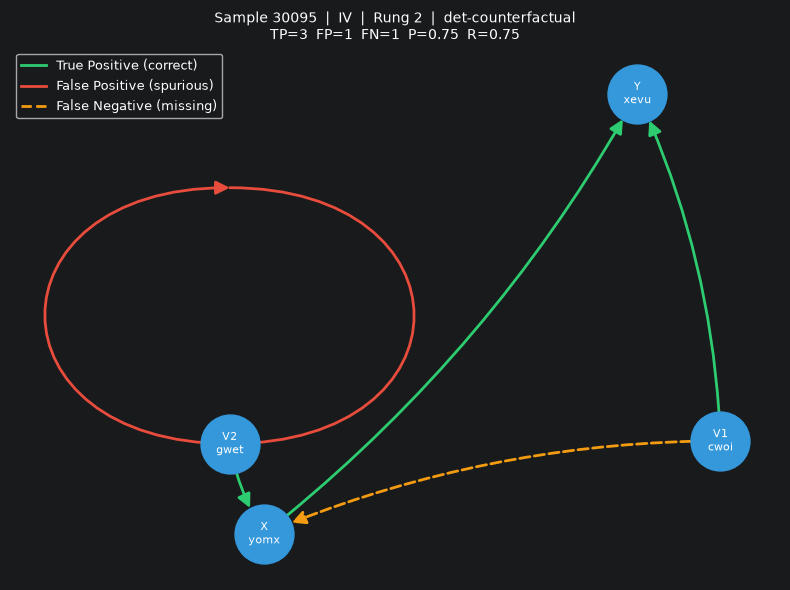

In [8]:
# Example Print a Graph from Validation Set to see what the model got wrong.
from graph_visualizer import visualize_graph_diff
from cadgn import GraphBuilder

test_sample = vald[10]
metrics, pred_embeds, edge_logits = trainer._stage1_step(sample=test_sample, config=s1c)
model_id = families[0].model_id
pred_edge_logits = edge_logits[model_id]
pairs_l = _generate_candidate_pairs(
        num_nodes=len(test_sample.node_names),
        device=trainer.device,
    )

pred_edges = GraphBuilder.to_edges(pred_edge_logits, candidate_pairs=pairs_l, threshold=0.5)
#print(test_sample.data.edge_index, "\n", pred_edges)

# Make a spurious edge and missing edge (for demonstrative purposes)
pred_edge_logits[0] = -1 * pred_edge_logits[0]
pred_edge_logits[6] = -1 * pred_edge_logits[6]

print(GraphBuilder.to_edges(pred_edge_logits, candidate_pairs=pairs_l, threshold=0.5), "\n", pred_edges)

fig = visualize_graph_diff(
    sample=test_sample,
    edge_logits=edge_logits[model_id],
    candidate_pairs=pairs_l
)

#fig.savefig(f"graph_diff_{test_sample.sample_id}.png", dpi=150)